# Lab 6

You are tasked with evaluating card counting strategies for black jack. In order to do so, you will use object oriented programming to create a playable casino style black jack game where a computer dealer plays against $n$ computer players and possibily one human player. If you don't know the rules of blackjack or card counting, please google it. 

A few requirements:
* The game should utilize multiple 52-card decks. Typically the game is played with 6 decks.
* Players should have chips.
* Dealer's actions are predefined by rules of the game (typically hit on 16). 
* The players should be aware of all shown cards so that they can count cards.
* Each player could have a different strategy.
* The system should allow you to play large numbers of games, study the outcomes, and compare average winnings per hand rate for different strategies.

1. Begin by creating a classes to represent cards and decks. The deck should support more than one 52-card set. The deck should allow you to shuffle and draw cards. Include a "plastic" card, placed randomly in the deck. Later, when the plastic card is dealt, shuffle the cards before the next deal.

In [1]:
import random

class Card:
    def __init__(self, rank, suit):
        # each card has a rank and suit
        self.rank = rank
        self.suit = suit

    def value(self):
        # blackjack values
        if self.rank in ['J', 'Q', 'K']:
            return 10
        elif self.rank == 'A':
            return 11
        else:
            return int(self.rank)

    def __str__(self):
        return f"{self.rank} of {self.suit}"

In [2]:
class Deck:
    def __init__(self, num_decks=6):
        # I used multiple decks because blackjack in casinos usually uses 6
        self.num_decks = num_decks
        self.cards = []
        self.build_deck()
        self.insert_plastic_card()

    def build_deck(self):
        suits = ['Hearts', 'Diamonds', 'Clubs', 'Spades']
        ranks = ['2','3','4','5','6','7','8','9','10','J','Q','K','A']

        # create all cards for all decks
        for _ in range(self.num_decks):
            for suit in suits:
                for rank in ranks:
                    self.cards.append(Card(rank, suit))

    def shuffle(self):
        # shuffle the deck before dealing
        random.shuffle(self.cards)

    def draw(self):
        # draw the top card
        if len(self.cards) == 0:
            return None
        return self.cards.pop()

    def insert_plastic_card(self):
        # the plastic card tells us when to reshuffle
        # I wasn't sure exactly where casinos place it, so I just put it randomly
        position = random.randint(0, len(self.cards))
        self.cards.insert(position, "PLASTIC")

2. Now design your game on a UML diagram. You may want to create classes to represent, players, a hand, and/or the game. As you work through the lab, update your UML diagram. At the end of the lab, submit your diagram (as pdf file) along with your notebook. 

3. Begin with implementing the skeleton (ie define data members and methods/functions, but do not code the logic) of the classes in your UML diagram.

In [3]:
class Card:
    def __init__(self, rank, suit):
        self.rank = rank
        self.suit = suit

    def value(self):
        pass

In [4]:
class Deck:
    def __init__(self, num_decks=6):
        self.num_decks = num_decks
        self.cards = []

    def build_deck(self):
        pass

    def shuffle(self):
        pass

    def draw(self):
        pass

In [5]:
class Hand:
    def __init__(self):
        self.cards = []

    def add_card(self, card):
        pass

    def value(self):
        pass

In [6]:
class Player:
    def __init__(self, chips=100):
        self.chips = chips
        self.hand = Hand()

    def play_turn(self, deck):
        pass

In [7]:
class Dealer:
    def __init__(self):
        self.hand = Hand()

    def play_turn(self, deck):
        pass

In [8]:
class Game:
    def __init__(self):
        self.players = []
        self.dealer = Dealer()
        self.deck = Deck()

    def play_round(self):
        pass

4. Complete the implementation by coding the logic of all functions. For now, just implement the dealer player and human player.

In [15]:
class Card:

    def __init__(self, rank, suit):
        self.rank = rank
        self.suit = suit

    def value(self):
        # determines blackjack value of the card
        # face cards count as 10
        if self.rank in ['J','Q','K']:
            return 10
        
        # ace starts as 11
        elif self.rank == 'A':
            return 11
        
        else:
            return int(self.rank)
        
    def __str__(self):
        # makes printing cards easier to read
        return f"{self.rank}-{self.suit}"

In [38]:
class Deck:

    def __init__(self, num_decks=6):
        # used 6 decks here
        self.cards = []
        ranks = ['2','3','4','5','6','7','8','9','10','J','Q','K','A']
        suits = ['H','D','C','S']

        # build all cards for all decks
        for _ in range(num_decks):
            for s in suits:
                for r in ranks:
                    self.cards.append(Card(r,s))
        # shuffle once the deck is created
        random.shuffle(self.cards)

    def draw(self):
        # draw the top card from the deck
        return self.cards.pop()
    
    def draw(self):

        # if the deck runs out of cards, rebuild and reshuffle it 
        # I added this because during long simulations the deck can become empty
        if len(self.cards) == 0:

            self.__init__()  # rebuild the deck

        return self.cards.pop()

In [30]:
class Hand:

    def __init__(self):
        # a hand just keeps track of cards a player has
        self.cards = []

    def add_card(self, card):
        # adds a new card to the hand
        self.cards.append(card)

    def value(self):
        # calculates total value of the hand
        total = 0
        aces = 0

        for c in self.cards:

            total += c.value()

            if c.rank == 'A':
                aces += 1
        # adjust ace values if bust
        while total > 21 and aces > 0:
            total -= 10
            aces -= 1

        return total
    
    def show(self):
        # return cards as a string so we can print them
        return ", ".join(str(c) for c in self.cards) 

In [13]:
class Dealer:
    
    def __init__(self):
        self.hand = Hand()

    def play_turn(self, deck):
        # dealer hits until 16
        while self.hand.value() < 16:

            self.hand.add_card(deck.draw())

In [19]:
class Player:
    def __init__(self, name):
        self.name = name
        self.hand = Hand()

    def play_turn(self, deck):
        # I made it so that hit until hand value is at least 16, like what the dealer does
        while self.hand.value() < 16:

            self.hand.add_card(deck.draw())

5.  Test. Demonstrate game play. For example, create a game of several dealer players and show that the game is functional through several rounds.

In [31]:
class Game:

    def __init__(self, num_players=3):
        # create the deck and dealer
        self.deck = Deck()
        self.dealer = Dealer()

        # create several players
        self.players = []

        for i in range(num_players):
            self.players.append(Player(f"Player {i+1}"))

    def deal_initial_cards(self):
        # give two cards to each player and dealer
        for _ in range(2):

            for p in self.players:
                p.hand.add_card(self.deck.draw())

            self.dealer.hand.add_card(self.deck.draw())

    def play_round(self):
        # reset hands for a new round
        self.dealer.hand = Hand()

        for p in self.players:
            p.hand = Hand()

        # deals initial cards
        self.deal_initial_cards()

        print("\n--- New Round ---")

        # show player hands
        for p in self.players:
            print(p.name, "has:", p.hand.show(), "value:", p.hand.value())

        print("Dealer has:", self.dealer.hand.show())

        # players take their turns
        for p in self.players:
            p.play_turn(self.deck)

        # dealer takes turn
        self.dealer.play_turn(self.deck)

        dealer_value = self.dealer.hand.value()

        print("Dealer final hand:", self.dealer.hand.show(), "value:", dealer_value)

        # determine winner for each player
        for p in self.players:

            player_value = p.hand.value()

            print(p.name, "final value:", player_value)

            if player_value > 21:
                print(p.name, "busts")

            elif dealer_value > 21 or player_value > dealer_value:
                print(p.name, "wins")

            elif player_value == dealer_value:
                print(p.name, "push")

            else:
                print(p.name, "loses")

In [32]:
game = Game(num_players=3)

for i in range(5):
    game.play_round()


--- New Round ---
Player 1 has: A-S, 7-H value: 18
Player 2 has: 2-H, 10-C value: 12
Player 3 has: 2-H, 6-C value: 8
Dealer has: K-H, 6-S
Dealer final hand: K-H, 6-S value: 16
Player 1 final value: 18
Player 1 wins
Player 2 final value: 25
Player 2 busts
Player 3 final value: 19
Player 3 wins

--- New Round ---
Player 1 has: J-H, 9-H value: 19
Player 2 has: J-C, 3-C value: 13
Player 3 has: 8-D, 4-C value: 12
Dealer has: 10-C, K-C
Dealer final hand: 10-C, K-C value: 20
Player 1 final value: 19
Player 1 loses
Player 2 final value: 22
Player 2 busts
Player 3 final value: 22
Player 3 busts

--- New Round ---
Player 1 has: Q-S, A-D value: 21
Player 2 has: 5-S, 3-C value: 8
Player 3 has: 9-C, 7-H value: 16
Dealer has: 7-S, 8-C
Dealer final hand: 7-S, 8-C, 6-S value: 21
Player 1 final value: 21
Player 1 push
Player 2 final value: 17
Player 2 loses
Player 3 final value: 16
Player 3 loses

--- New Round ---
Player 1 has: 7-S, J-H value: 17
Player 2 has: 9-D, 3-S value: 12
Player 3 has: J-D, 2-

6. Implement a new player with the following strategy:

    * Assign each card a value: 
        * Cards 2 to 6 are +1 
        * Cards 7 to 9 are 0 
        * Cards 10 through Ace are -1
    * Compute the sum of the values for all cards seen so far.
    * Hit if sum is very negative, stay if sum is very positive. Select a threshold for hit/stay, e.g. 0 or -2.  

In [33]:
class StrategyPlayer(Player):

    def __init__(self, name, threshold=0, chips=100):
        # use the Player constructor
        super().__init__(name)

        self.count = 0
        self.threshold = threshold
        self.chips = chips


    def update_count(self, card):
        # update the running card count
        if card.rank in ['2','3','4','5','6']:
            self.count += 1

        elif card.rank in ['10','J','Q','K','A']:
            self.count -= 1


    def play_turn(self, deck):
        # this player uses the card count to decide whether to hit

        while self.hand.value() < 21:

            # if the count is negative enough, we keep hitting
            if self.count <= self.threshold:

                card = deck.draw()

                self.update_count(card)

                self.hand.add_card(card)

            else:
                break

7. Create a test scenario where one player, using the above strategy, is playing with a dealer and 3 other players that follow the dealer's strategy. Each player starts with same number of chips. Play 50 rounds (or until the strategy player is out of money). Compute the strategy player's winnings. You may remove unnecessary printouts from your code (perhaps implement a verbose/quiet mode) to reduce the output.

In [36]:
def run_test_game(rounds=50):
    deck = Deck()

    dealer = Dealer()

    strategy_player = StrategyPlayer("Strategy Player", threshold=0)

    players = [Player("Player 1"), Player("Player 2"), Player("Player 3")]

    for r in range(rounds):
        # reset hands each round
        dealer.hand = Hand()
        strategy_player.hand = Hand()

        for p in players:
            p.hand = Hand()

        # deal initial cards
        for _ in range(2):
            card = deck.draw()
            strategy_player.hand.add_card(card)
            strategy_player.update_count(card)

            dealer.hand.add_card(deck.draw())

            for p in players:
                p.hand.add_card(deck.draw())

        # play turns
        strategy_player.play_turn(deck)

        for p in players:
            p.play_turn(deck)

        dealer.play_turn(deck)

        dealer_value = dealer.hand.value()
        player_value = strategy_player.hand.value()

        # update chips
        if player_value <= 21 and (dealer_value > 21 or player_value > dealer_value):

            strategy_player.chips += 1

        else:

            strategy_player.chips -= 1

        # stop if player runs out of chips
        if strategy_player.chips <= 0:
            break

    return strategy_player.chips

In [39]:
# I ran this first just to make sure the simulation works before running the larger 100 game experiment

winnings = run_test_game(50)
print("Strategy player final chips after 50 rounds:", winnings)

Strategy player final chips after 50 rounds: 76


8. Create a loop that runs 100 games of 50 rounds, as setup in previous question, and store the strategy player's chips at the end of the game (aka "winnings") in a list. Histogram the winnings. What is the average winnings per round? What is the standard deviation. What is the probabilty of net winning or lossing after 50 rounds?


In [40]:
results = []

for i in range(100):
    winnings = run_test_game(50)

    results.append(winnings)

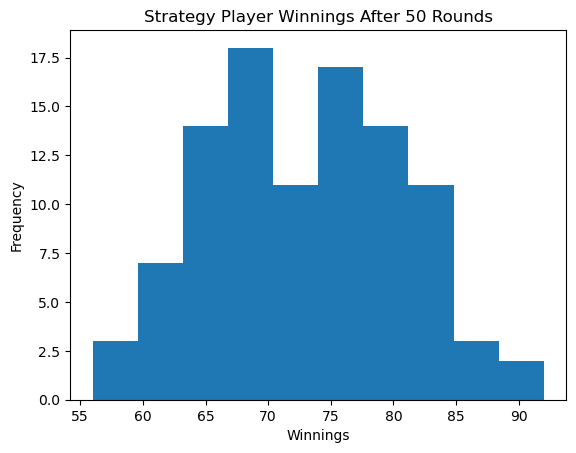

In [44]:
import matplotlib.pyplot as plt

plt.hist(results, bins=10)

plt.title("Strategy Player Winnings After 50 Rounds")
plt.xlabel("Winnings")
plt.ylabel("Frequency")

plt.show()

In [47]:
avg = sum(results) / len(results)
print("Average:",avg)

Average: 72.96


In [48]:
variance = sum((x - avg)**2 for x in results) / len(results)
std_dev = (variance)**0.5
print("Standard Deviation:",std_dev)

Standard Deviation: 7.681041596033705


In [49]:
wins = len([x for x in results if x > 0])
prob_win = wins / len(results)
print("Probabilty:",prob_win)

Probabilty: 1.0


9. Repeat previous questions scanning the value of the threshold. Try at least 5 different threshold values. Can you find an optimal value?

In [50]:
thresholds = [-3, -2, -1, 0, 1]

for t in thresholds:
    results = []

    for i in range(100):
        winnings = run_test_game(50)

        results.append(winnings)

    avg = sum(results)/len(results)
    print("Threshold:", t, "Average winnings:", avg)

Threshold: -3 Average winnings: 73.06
Threshold: -2 Average winnings: 74.24
Threshold: -1 Average winnings: 76.2
Threshold: 0 Average winnings: 74.62
Threshold: 1 Average winnings: 75.84


I think the optimal value is somewhere inbetween -1 and 0, could be a decimal value.

10. Create a new strategy based on web searches or your own ideas. Demonstrate that the new strategy will result in increased or decreased winnings. 

From research I decided to modified strategy where the player adjusts their hit threshold depending on the card count, based on professional Black Jack players. When the count is very negative, the player assumes that many high cards remain in the deck and becomes more aggressive by hitting until a higher hand value. When the count is positive, the player becomes more conservative and stays earlier.

In [67]:
class AggressiveHighCardPlayer(Player):

    def __init__(self, name, chips=100):
        # use the Player constructor
        super().__init__(name)

        self.chips = chips

        # running count for card counting
        self.count = 0


    def update_count(self, card):
        # update running count based on card value, followed the same card counting system from earlier
        if card.rank in ['2','3','4','5','6']:
            self.count += 1

        elif card.rank in ['10','J','Q','K','A']:
            self.count -= 1


    def play_turn(self, deck):
        # this strategy changes the hit threshold depending on the count,I tried a few values and these seemed reasonable
        if self.count < -3:
            hit_threshold = 18   # very aggressive

        elif self.count > 3:
            hit_threshold = 14   # more conservative

        else:
            hit_threshold = 16   # normal blackjack style

        # now take cards until reaching the threshold
        while self.hand.value() < hit_threshold:

            card = deck.draw()

            self.update_count(card)

            self.hand.add_card(card)

In [69]:
# same as the run_test_game funcation, but just using the AggressiveHighCardPlayer class instead
def run_aggressive_test(rounds=50):

    deck = Deck()

    dealer = Dealer()

    strategy_player = AggressiveHighCardPlayer("Aggressive Player")

    players = [Player("Player 1"),Player("Player 2"),Player("Player 3")]

    for r in range(rounds):
        # reset hands every round
        dealer.hand = Hand()
        strategy_player.hand = Hand()

        for p in players:
            p.hand = Hand()

        # deal initial cards
        for _ in range(2):

            card = deck.draw()
            strategy_player.hand.add_card(card)
            strategy_player.update_count(card)

            dealer.hand.add_card(deck.draw())

            for p in players:
                p.hand.add_card(deck.draw())

        # play turns
        strategy_player.play_turn(deck)

        for p in players:
            p.play_turn(deck)

        dealer.play_turn(deck)

        dealer_value = dealer.hand.value()
        player_value = strategy_player.hand.value()

        # update chips
        if player_value <= 21 and (dealer_value > 21 or player_value > dealer_value):
            strategy_player.chips += 1

        else:
            strategy_player.chips -= 1

        # stop early if player loses all chips
        if strategy_player.chips <= 0:
            break

    return strategy_player.chips

In [70]:
# run one test game to make sure the strategy works
winnings = run_aggressive_test(50)
print("Aggressive strategy final chips after 50 rounds:", winnings)

Aggressive strategy final chips after 50 rounds: 96


In [71]:
results = []

for i in range(100):
    winnings = run_aggressive_test(50)
    results.append(winnings)

mean = sum(results)/len(results)
print("Average winnings:", mean)

Average winnings: 92.36


So this shows that this strategy significantly increases the average winnings compared to the original threshold strategy.